# 03 — Linear Regression: Complete Guide

**Learning sequence:** Problem → Intuition → Mathematics → From Scratch → Scikit-learn → Evaluation → Diagnostics → Failure Cases

This notebook connects the mathematical foundations of Linear Regression with practical implementation and model diagnosis.

## Learning Objectives

By the end of this notebook, you should be able to:

- Explain Simple and Multiple Linear Regression.
- Understand OLS, MSE, RMSE, R², and the Normal Equation.
- Implement Linear Regression from scratch.
- Understand Gradient Descent and learning rate.
- Use `LinearRegression` from scikit-learn.
- Work with a built-in regression dataset.
- Evaluate predictions with several regression metrics.
- Diagnose residuals, outliers, multicollinearity, and extrapolation.
- Demonstrate Underfitting and Overfitting with Polynomial Regression.
- Understand how model complexity affects generalization.

In [1]:
# Import NumPy for numerical computation.
import numpy as np

# Import pandas for tabular data analysis.
import pandas as pd

# Import Matplotlib for visualization.
import matplotlib.pyplot as plt

# Import Seaborn for statistical visualization.
import seaborn as sns

# Use a clean plotting theme.
sns.set_theme(style="ticks", context="notebook")

# 1. Regression vs Classification

Regression predicts a **continuous numerical target**.

Examples:

- House price
- Temperature
- Tumor volume
- Survival time

Classification predicts discrete classes such as benign/malignant.

---

# 2. Simple Linear Regression

The basic model is:

$$
\hat{y} = \beta_0 + \beta_1 x
$$

where $\beta_0$ is the intercept and $\beta_1$ is the slope.

The residual is:

$$
e_i = y_i - \hat{y}_i
$$

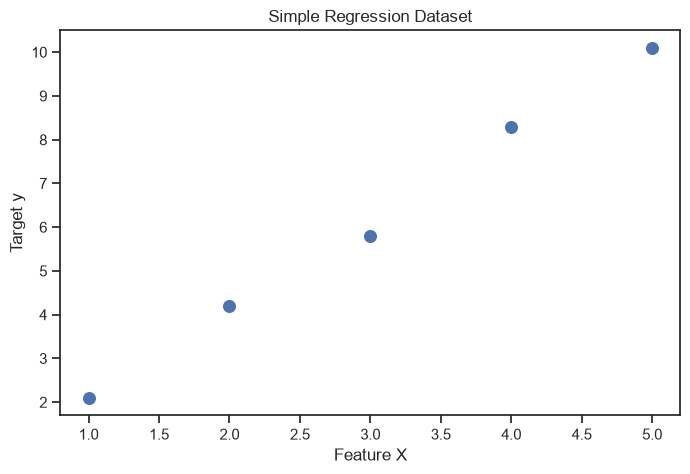

In [2]:
# Create a small synthetic regression dataset.
X_simple = np.array([1, 2, 3, 4, 5], dtype=float)
y_simple = np.array([2.1, 4.2, 5.8, 8.3, 10.1], dtype=float)

# Visualize the observations.
plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y_simple, s=70)
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.title("Simple Regression Dataset")
plt.show()

# 3. Loss Function: SSE, MSE, and RMSE

Ordinary Least Squares minimizes:

$$
SSE = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Mean Squared Error:

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Root Mean Squared Error:

$$
RMSE = \sqrt{MSE}
$$

Residuals: [-0.7 -0.4 -0.6  0.1  0.1]
SSE: 1.03
MSE: 0.20600000000000002


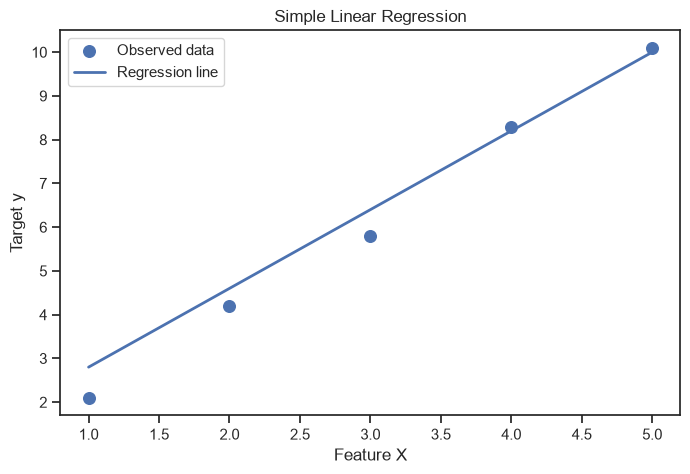

In [3]:
# Define an example regression line.
beta_0 = 1.0
beta_1 = 1.8

# Generate predictions.
y_hat = beta_0 + beta_1 * X_simple

# Calculate residuals.
residuals = y_simple - y_hat

# Calculate SSE and MSE.
sse = np.sum(residuals ** 2)
mse = np.mean(residuals ** 2)

print("Residuals:", residuals)
print("SSE:", sse)
print("MSE:", mse)

# Plot the observations and regression line.
plt.figure(figsize=(8, 5))
plt.scatter(X_simple, y_simple, s=70, label="Observed data")
plt.plot(X_simple, y_hat, linewidth=2, label="Regression line")
plt.xlabel("Feature X")
plt.ylabel("Target y")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

# 4. Multiple Linear Regression

With multiple features:

$$
\hat{y} =
\beta_0+\beta_1x_1+\beta_2x_2+\cdots+\beta_px_p
$$

In matrix form:

$$
\hat{y}=X\beta
$$

This formulation is the foundation of practical Linear Regression.

# 5. Ordinary Least Squares and the Normal Equation

The closed-form OLS solution is:

$$
\beta=(X^TX)^{-1}X^Ty
$$

In numerical computing, `np.linalg.lstsq` is generally preferred to explicitly calculating the inverse because it is more numerically stable.

In [4]:
# Add a column of ones to represent the intercept.
X_design = np.c_[np.ones(len(X_simple)), X_simple]

# Solve the least-squares problem with a numerically stable solver.
beta = np.linalg.lstsq(X_design, y_simple, rcond=None)[0]

# Display the learned parameters.
print("Intercept:", beta[0])
print("Slope:", beta[1])

Intercept: 0.07000000000000318
Slope: 2.0099999999999993


# 6. Linear Regression From Scratch

We implement the least-squares solution ourselves so the connection between the mathematics and the algorithm is explicit.

In [5]:
# Define a reusable least-squares Linear Regression function.
def linear_regression_from_scratch(X, y):
    # Convert inputs to floating-point NumPy arrays.
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).ravel()

    # Add a column of ones for the intercept.
    X_design = np.c_[np.ones(X.shape[0]), X]

    # Solve the least-squares optimization problem.
    parameters = np.linalg.lstsq(
        X_design,
        y,
        rcond=None
    )[0]

    # Return feature coefficients and intercept separately.
    return parameters[1:], parameters[0]

# Fit the scratch implementation.
coef, intercept = linear_regression_from_scratch(
    X_simple.reshape(-1, 1),
    y_simple
)

print("Coefficients:", coef)
print("Intercept:", intercept)

Coefficients: [2.01]
Intercept: 0.07000000000000318


# 7. Gradient Descent

For the MSE objective:

$$
J(\beta)=\frac{1}{n}\|X\beta-y\|^2
$$

the gradient is:

$$
\nabla J(\beta)=\frac{2}{n}X^T(X\beta-y)
$$

The update rule is:

$$
\beta \leftarrow \beta-\alpha\nabla J(\beta)
$$

where $\alpha$ is the learning rate.

In [6]:
# Define Linear Regression trained with batch Gradient Descent.
def linear_regression_gradient_descent(
    X,
    y,
    learning_rate=0.01,
    n_iterations=1000
):
    # Convert inputs to floating-point arrays.
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float).ravel()

    # Get the number of samples and features.
    n_samples, n_features = X.shape

    # Initialize weights and intercept.
    weights = np.zeros(n_features)
    bias = 0.0

    # Store MSE at every iteration.
    loss_history = []

    # Repeat the optimization process.
    for _ in range(n_iterations):

        # Calculate current predictions.
        predictions = X @ weights + bias

        # Calculate prediction errors.
        errors = predictions - y

        # Calculate the weight gradient.
        weight_gradient = (2 / n_samples) * (X.T @ errors)

        # Calculate the intercept gradient.
        bias_gradient = (2 / n_samples) * np.sum(errors)

        # Update the parameters.
        weights -= learning_rate * weight_gradient
        bias -= learning_rate * bias_gradient

        # Record the current MSE.
        current_mse = np.mean((X @ weights + bias - y) ** 2)
        loss_history.append(current_mse)

    return weights, bias, loss_history

# Train the model with Gradient Descent.
weights, bias, losses = linear_regression_gradient_descent(
    X_simple.reshape(-1, 1),
    y_simple,
    learning_rate=0.01,
    n_iterations=2000
)

print("Weight:", weights)
print("Bias:", bias)

Weight: [2.00985678]
Bias: 0.07051707108658381


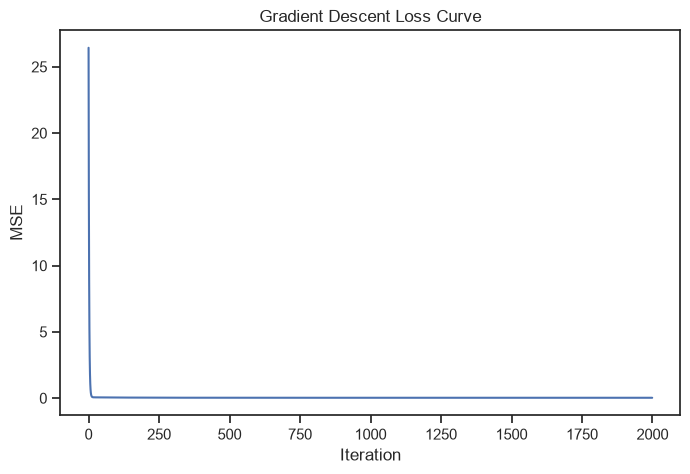

In [7]:
# Plot the optimization loss.
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent Loss Curve")
plt.show()

# 8. Scikit-learn Implementation

After understanding the mathematics and a from-scratch implementation, we can use the standard scikit-learn estimator.

In [8]:
# Import Linear Regression from scikit-learn.
from sklearn.linear_model import LinearRegression

# Create the estimator.
model = LinearRegression()

# Fit the model.
model.fit(X_simple.reshape(-1, 1), y_simple)

# Display the learned parameters.
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [2.01]
Intercept: 0.06999999999999851


# 9. Built-in Regression Dataset: Diabetes

`load_diabetes()` is a built-in continuous regression dataset. It is useful for learning regression workflows and should not be interpreted as a clinical diagnostic model.

In [9]:
# Import the built-in Diabetes regression dataset.
from sklearn.datasets import load_diabetes

# Load the dataset.
diabetes = load_diabetes()

# Extract features and target.
X_diabetes = diabetes.data
y_diabetes = diabetes.target

# Display dataset dimensions and feature names.
print("Feature matrix shape:", X_diabetes.shape)
print("Target shape:", y_diabetes.shape)
print("Feature names:", diabetes.feature_names)

Feature matrix shape: (442, 10)
Target shape: (442,)
Feature names: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [10]:
# Convert the dataset into a DataFrame.
diabetes_df = pd.DataFrame(
    X_diabetes,
    columns=diabetes.feature_names
)

# Add the continuous target.
diabetes_df["target"] = y_diabetes

# Display the first five rows.
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


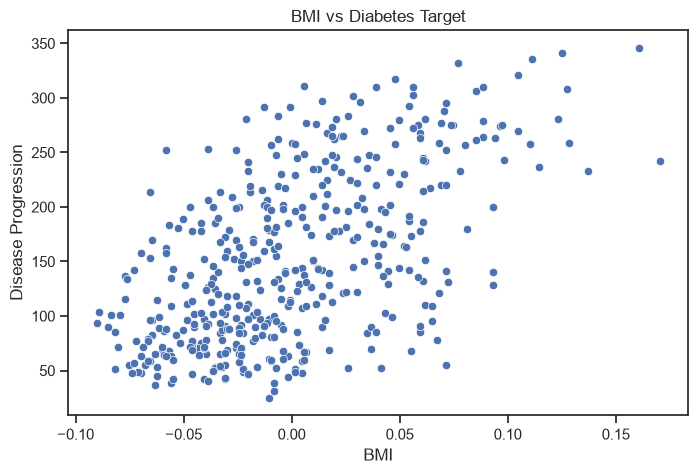

In [11]:
# Visualize one feature against the target.
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=diabetes_df,
    x="bmi",
    y="target"
)
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("BMI vs Diabetes Target")
plt.show()

# 10. Train / Validation / Test Split

The training set fits parameters.

The validation set supports model-selection decisions.

The test set is reserved for final evaluation.

The exact proportions are context-dependent; preventing information leakage is the key principle.

In [12]:
# Import the splitting utility.
from sklearn.model_selection import train_test_split

# Create training and temporary partitions.
X_train, X_temp, y_train, y_temp = train_test_split(
    X_diabetes,
    y_diabetes,
    test_size=0.30,
    random_state=42
)

# Split the temporary data into validation and test sets.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Display the resulting sample counts.
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 309
Validation samples: 66
Test samples: 67


In [13]:
# Fit Linear Regression using training data only.
diabetes_model = LinearRegression()
diabetes_model.fit(X_train, y_train)

# Generate validation and test predictions.
y_val_pred = diabetes_model.predict(X_val)
y_test_pred = diabetes_model.predict(X_test)

# Display a few test predictions.
print(y_test_pred[:5])

[ 63.8874565  143.53425629  91.35065005 166.15280313 135.0455994 ]


# 11. Regression Evaluation Metrics

### MAE

$$
MAE=\frac{1}{n}\sum|y_i-\hat{y}_i|
$$

### MSE

$$
MSE=\frac{1}{n}\sum(y_i-\hat{y}_i)^2
$$

### RMSE

$$
RMSE=\sqrt{MSE}
$$

### R²

$$
R^2=
1-
\frac{\sum(y_i-\hat{y}_i)^2}
{\sum(y_i-\bar y)^2}
$$

In [14]:
# Import standard regression metrics.
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Calculate test-set metrics.
mae = mean_absolute_error(y_test, y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_test_pred)

# Display the metrics.
print(f"MAE : {mae:.3f}")
print(f"MSE : {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²  : {r2:.3f}")

MAE : 45.567
MSE : 3139.368
RMSE: 56.030
R²  : 0.447


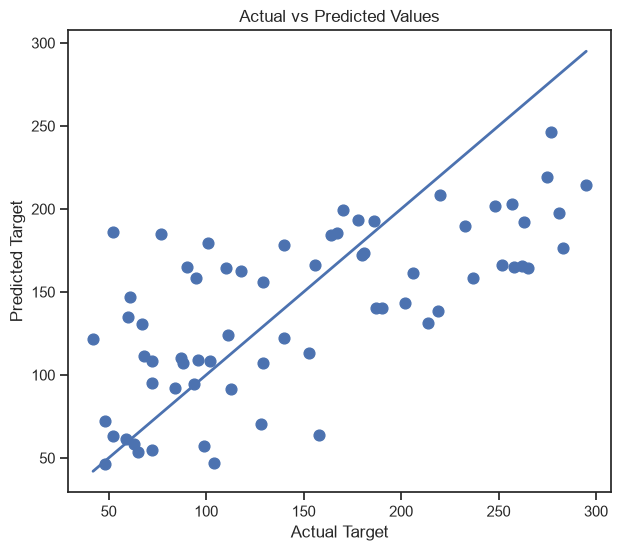

In [15]:
# Compare actual and predicted values.
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred, s=60)

# Draw the ideal y = x reference line.
line_min = min(y_test.min(), y_test_pred.min())
line_max = max(y_test.max(), y_test_pred.max())
plt.plot(
    [line_min, line_max],
    [line_min, line_max],
    linewidth=2
)

plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.title("Actual vs Predicted Values")
plt.show()

# 12. Residual Analysis

Residuals are:

$$
e_i=y_i-\hat{y}_i
$$

Residual plots can reveal nonlinearity, heteroscedasticity, outliers, and other systematic structure that a single metric may hide.

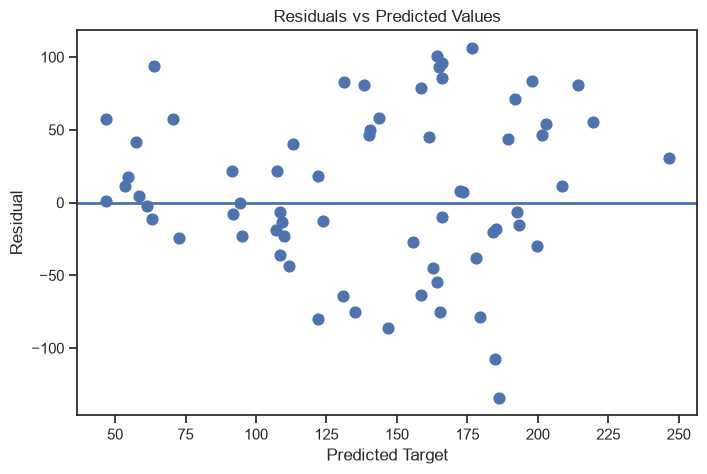

In [16]:
# Calculate residuals on the test set.
residuals_test = y_test - y_test_pred

# Plot residuals against predictions.
plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals_test, s=60)

# Add a zero-residual reference line.
plt.axhline(0, linewidth=2)

plt.xlabel("Predicted Target")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")
plt.show()

# 13. Polynomial Regression

Polynomial Regression adds transformed features such as $x^2$, $x^3$, and higher powers.

$$
\hat y=
\beta_0+\beta_1x+\beta_2x^2+\cdots+\beta_dx^d
$$

It is still linear in its parameters, so ordinary Linear Regression can fit the transformed feature matrix.

In [17]:
# Import tools for polynomial regression.
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Generate a nonlinear synthetic dataset.
rng = np.random.default_rng(42)

# Create feature values.
X_curve = np.linspace(-2.5, 2.5, 80).reshape(-1, 1)

# Add random observation noise.
noise = rng.normal(0, 3, size=len(X_curve))

# Construct the nonlinear target.
y_curve = (
    2 * X_curve[:, 0] ** 3
    - 3 * X_curve[:, 0] ** 2
    + X_curve[:, 0]
    + noise
)

# Split the data into training and test sets.
X_curve_train, X_curve_test, y_curve_train, y_curve_test = train_test_split(
    X_curve,
    y_curve,
    test_size=0.25,
    random_state=42
)

# 14. Underfitting and Overfitting

A low-degree model can be too simple and **underfit**.

A very high-degree polynomial can fit random noise and **overfit**.

The important principle is:

> Training performance is not the same as generalization performance.

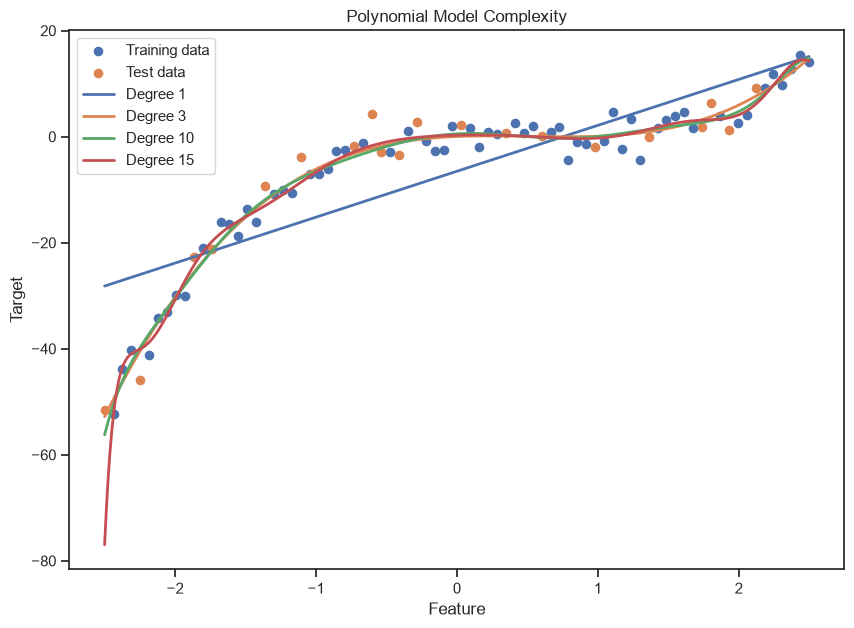

In [18]:
# Define polynomial degrees for visual comparison.
degrees = [1, 3, 10, 15]

# Create a smooth grid for plotting fitted curves.
X_plot = np.linspace(
    X_curve.min(),
    X_curve.max(),
    400
).reshape(-1, 1)

plt.figure(figsize=(10, 7))

# Plot the training observations.
plt.scatter(
    X_curve_train,
    y_curve_train,
    s=35,
    label="Training data"
)

# Plot the test observations.
plt.scatter(
    X_curve_test,
    y_curve_test,
    s=35,
    label="Test data"
)

# Fit and plot each polynomial model.
for degree in degrees:

    # Build a polynomial-feature + Linear Regression pipeline.
    poly_model = make_pipeline(
        PolynomialFeatures(
            degree=degree,
            include_bias=False
        ),
        LinearRegression()
    )

    # Fit using training data only.
    poly_model.fit(X_curve_train, y_curve_train)

    # Predict on the smooth plotting grid.
    y_plot = poly_model.predict(X_plot)

    # Plot the fitted curve.
    plt.plot(
        X_plot,
        y_plot,
        linewidth=2,
        label=f"Degree {degree}"
    )

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Polynomial Model Complexity")
plt.legend()
plt.show()

In [19]:
# Store performance results for polynomial degrees 1 through 15.
complexity_results = []

for degree in range(1, 16):

    # Build the polynomial regression pipeline.
    poly_model = make_pipeline(
        PolynomialFeatures(
            degree=degree,
            include_bias=False
        ),
        LinearRegression()
    )

    # Fit only on training data.
    poly_model.fit(X_curve_train, y_curve_train)

    # Predict training and test targets.
    train_pred = poly_model.predict(X_curve_train)
    test_pred = poly_model.predict(X_curve_test)

    # Store training and test performance.
    complexity_results.append({
        "degree": degree,
        "train_mse": mean_squared_error(y_curve_train, train_pred),
        "test_mse": mean_squared_error(y_curve_test, test_pred),
        "train_r2": r2_score(y_curve_train, train_pred),
        "test_r2": r2_score(y_curve_test, test_pred)
    })

# Convert the results to a DataFrame.
complexity_df = pd.DataFrame(complexity_results)

# Display the results.
complexity_df

,degree,train_mse,test_mse,train_r2,test_r2
0,1,55.527669,104.113219,0.746227,0.591801
1,2,28.591341,43.532244,0.869331,0.829322
2,3,4.430104,8.080823,0.979753,0.968317
3,4,4.421837,8.064896,0.979791,0.968380
4,5,4.387227,8.308878,0.979949,0.967423
5,6,4.387090,8.299275,0.979950,0.967461
6,7,4.382645,8.378729,0.979970,0.967149
7,8,4.381700,8.319213,0.979975,0.967383
8,9,4.373851,8.109517,0.980011,0.968205
9,10,4.230065,9.784419,0.980668,0.961638


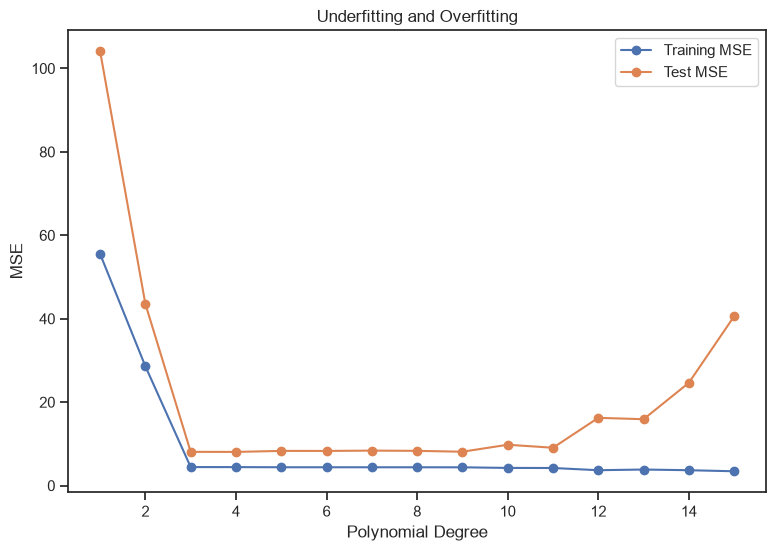

In [20]:
# Plot training and test MSE as complexity increases.
plt.figure(figsize=(9, 6))
plt.plot(
    complexity_df["degree"],
    complexity_df["train_mse"],
    marker="o",
    label="Training MSE"
)
plt.plot(
    complexity_df["degree"],
    complexity_df["test_mse"],
    marker="o",
    label="Test MSE"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("MSE")
plt.title("Underfitting and Overfitting")
plt.legend()
plt.show()

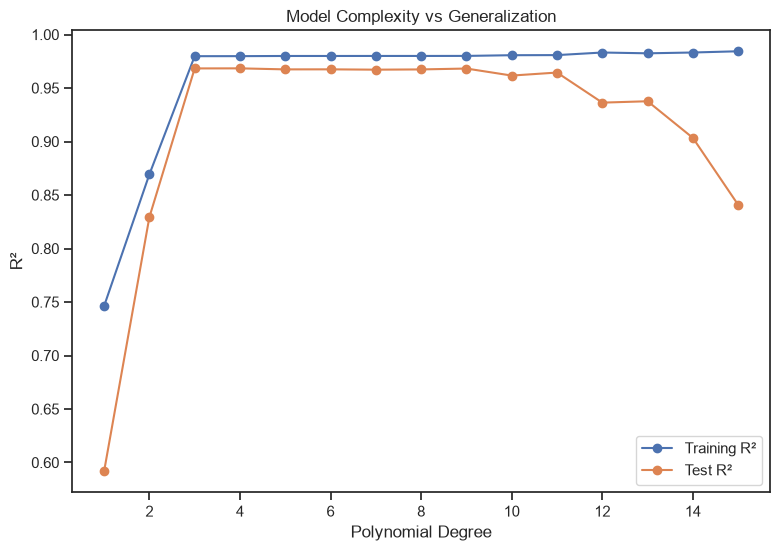

In [21]:
# Plot training and test R² as complexity increases.
plt.figure(figsize=(9, 6))
plt.plot(
    complexity_df["degree"],
    complexity_df["train_r2"],
    marker="o",
    label="Training R²"
)
plt.plot(
    complexity_df["degree"],
    complexity_df["test_r2"],
    marker="o",
    label="Test R²"
)

plt.xlabel("Polynomial Degree")
plt.ylabel("R²")
plt.title("Model Complexity vs Generalization")
plt.legend()
plt.show()

# 15. `mglearn`

`mglearn` is a teaching-oriented library associated with *Introduction to Machine Learning with Python*.

If it is not installed, run:

```python
%pip install mglearn
```

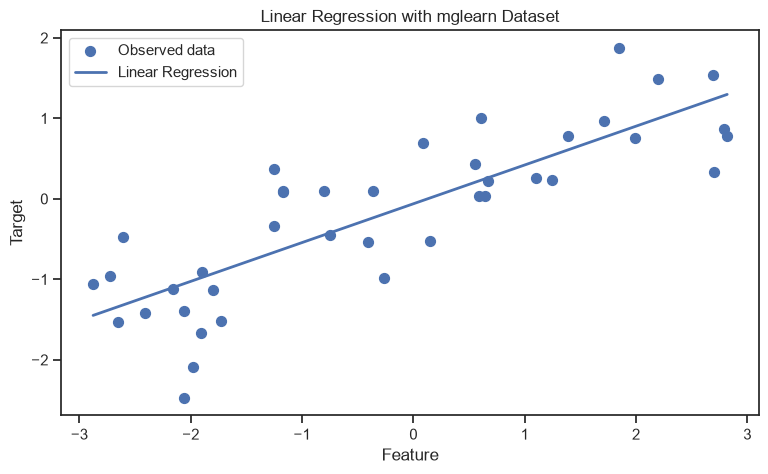

In [23]:
# Import mglearn for educational machine-learning datasets.
import mglearn

# Import Linear Regression from scikit-learn.
from sklearn.linear_model import LinearRegression

# Create a regression dataset using mglearn.
X_mglearn, y_mglearn = mglearn.datasets.make_wave(
    n_samples=40
)

# Create and fit a Linear Regression model.
mglearn_model = LinearRegression()
mglearn_model.fit(
    X_mglearn,
    y_mglearn
)

# Generate predictions for the observed feature values.
y_mglearn_pred = mglearn_model.predict(
    X_mglearn
)

# Sort the feature values so the regression line is plotted correctly.
sort_idx = np.argsort(
    X_mglearn[:, 0]
)

# Create the figure.
plt.figure(figsize=(9, 5))

# Plot the original observations.
plt.scatter(
    X_mglearn[:, 0],
    y_mglearn,
    s=50,
    label="Observed data"
)

# Plot the fitted Linear Regression line.
plt.plot(
    X_mglearn[sort_idx, 0],
    y_mglearn_pred[sort_idx],
    linewidth=2,
    label="Linear Regression"
)

# Add labels and title.
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Linear Regression with mglearn Dataset")

# Display the legend.
plt.legend()

# Display the plot.
plt.show()

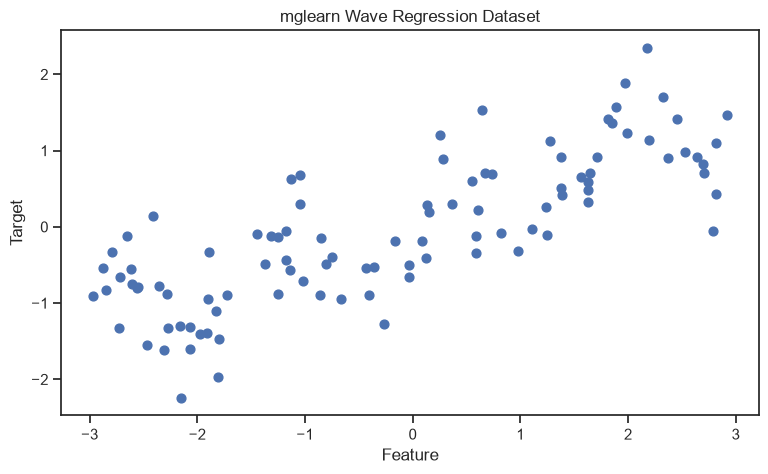

In [24]:
# Generate the mglearn wave regression dataset.
X_wave, y_wave = mglearn.datasets.make_wave(
    n_samples=100
)

# Visualize the dataset.
plt.figure(figsize=(9, 5))
plt.scatter(X_wave[:, 0], y_wave, s=40)
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("mglearn Wave Regression Dataset")
plt.show()

# 16. Feature Scaling and Data Leakage

Feature scaling is not inherently required for ordinary least squares, but it can matter for Gradient Descent because different feature scales affect optimization.

Safe workflow:

**Split → fit preprocessing on training data → transform validation/test using the fitted preprocessing.**

In [25]:
# Import StandardScaler and Pipeline.
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Build a leakage-safe scaling and regression pipeline.
scaled_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

# Fit the pipeline on training data only.
scaled_pipeline.fit(X_train, y_train)

# Predict the untouched test set.
pipeline_pred = scaled_pipeline.predict(X_test)

# Calculate the test RMSE.
pipeline_rmse = np.sqrt(
    mean_squared_error(y_test, pipeline_pred)
)

print("Pipeline test RMSE:", pipeline_rmse)

Pipeline test RMSE: 56.030066420159216


# 17. Outliers

OLS is sensitive to extreme observations because squared errors give large residuals disproportionately high influence.

An outlier should not automatically be removed. It may be a valid rare observation, a measurement problem, a data-entry error, or evidence of a different process.

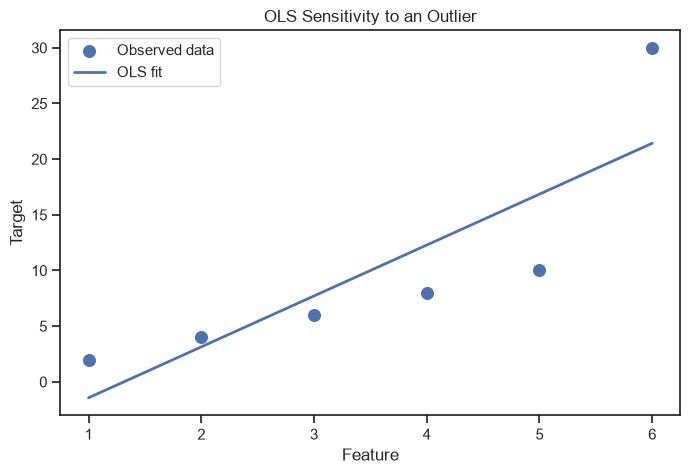

In [26]:
# Create a small dataset containing one extreme observation.
X_outlier = np.array(
    [1, 2, 3, 4, 5, 6],
    dtype=float
).reshape(-1, 1)

y_outlier = np.array(
    [2, 4, 6, 8, 10, 30],
    dtype=float
)

# Fit OLS with the extreme observation included.
outlier_model = LinearRegression()
outlier_model.fit(X_outlier, y_outlier)

# Generate fitted predictions.
y_outlier_pred = outlier_model.predict(X_outlier)

# Visualize the effect of the outlier.
plt.figure(figsize=(8, 5))
plt.scatter(
    X_outlier,
    y_outlier,
    s=70,
    label="Observed data"
)
plt.plot(
    X_outlier,
    y_outlier_pred,
    linewidth=2,
    label="OLS fit"
)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("OLS Sensitivity to an Outlier")
plt.legend()
plt.show()

# 18. Multicollinearity

Multicollinearity occurs when predictors contain strong linear relationships with one another.

It can cause:

- unstable coefficient estimates
- difficult coefficient interpretation
- sensitivity to small changes in the data

Predictions can still be useful even when individual coefficient interpretations are unstable.

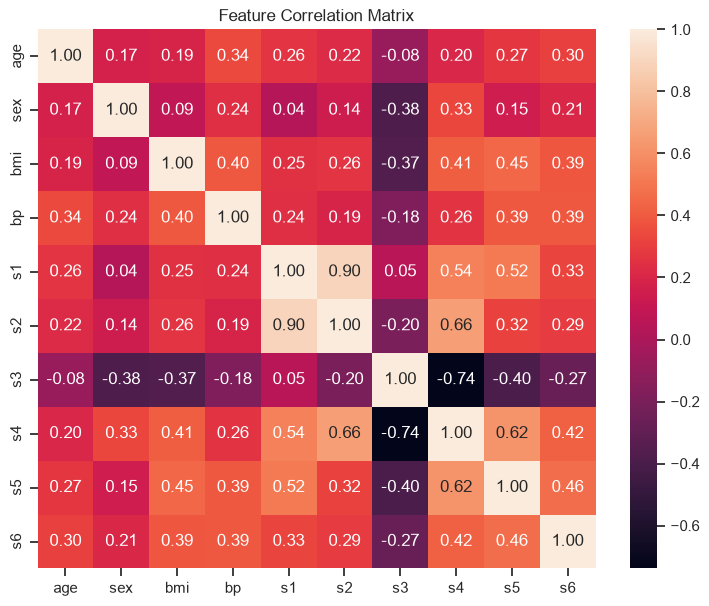

In [27]:
# Compute the correlation matrix for the Diabetes predictors.
correlation_matrix = diabetes_df.drop(
    columns="target"
).corr()

# Visualize feature correlations.
plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)
plt.title("Feature Correlation Matrix")
plt.show()

# 19. Extrapolation

**Interpolation** predicts within the observed feature range.

**Extrapolation** predicts outside it.

A fitted line can extend indefinitely mathematically, but the real-world relationship may not remain linear outside the observed range.

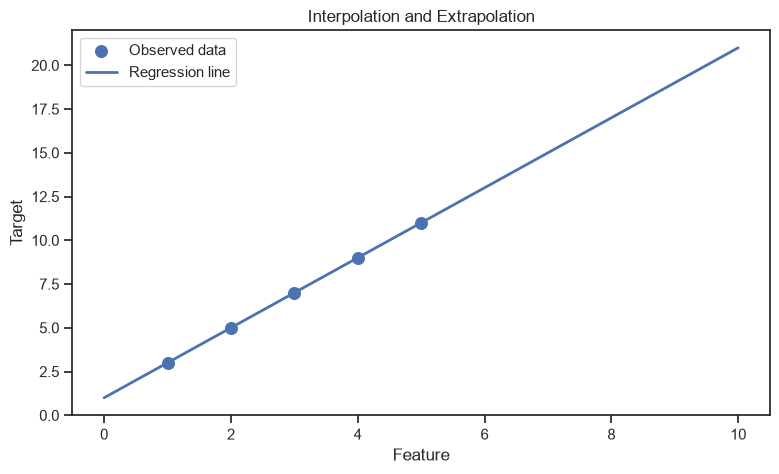

In [28]:
# Create a small observed range.
X_obs = np.array(
    [1, 2, 3, 4, 5],
    dtype=float
).reshape(-1, 1)

y_obs = np.array(
    [3, 5, 7, 9, 11],
    dtype=float
)

# Fit a Linear Regression model.
extra_model = LinearRegression()
extra_model.fit(X_obs, y_obs)

# Generate predictions inside and outside the observed range.
X_extended = np.linspace(
    0,
    10,
    100
).reshape(-1, 1)

y_extended = extra_model.predict(X_extended)

# Visualize the observed data and extended line.
plt.figure(figsize=(9, 5))
plt.scatter(
    X_obs,
    y_obs,
    s=70,
    label="Observed data"
)
plt.plot(
    X_extended,
    y_extended,
    linewidth=2,
    label="Regression line"
)

plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("Interpolation and Extrapolation")
plt.legend()
plt.show()

# 20. Bias, Variance, and Generalization

**High bias** usually corresponds to a model that is too simple and underfits.

**High variance** usually corresponds to a model that is too flexible and overfits.

The goal is not minimum training error. The goal is good performance on unseen data.

# 21. Classical Linear Regression Assumptions

Important assumptions include:

1. **Linearity** of the conditional mean.
2. **Independence** appropriate to the sampling/design context.
3. **Homoscedasticity** when classical inferential assumptions are used.
4. No severe **multicollinearity** when stable coefficient interpretation is required.
5. Residual normality is mainly relevant to certain small-sample inferential procedures; it is not a universal requirement for obtaining OLS predictions.

# 22. Common Failure Modes

- Treating a high R² as proof that a model is appropriate.
- Preprocessing before splitting the data.
- Looking repeatedly at the test set during model development.
- Ignoring residual patterns.
- Removing outliers without domain justification.
- Extrapolating far beyond the training range.
- Interpreting correlated feature coefficients as independent effects.
- Increasing polynomial degree without monitoring generalization.

### 33. Linear Regression Mastery Checklist

Use this checklist to verify that you understand Linear Regression beyond simply using the scikit-learn API.

### Conceptual understanding

* I can explain what Linear Regression does.
* I understand the difference between a feature, target, coefficient, and intercept.
* I understand the difference between simple and multiple Linear Regression.
* I understand the equation of a Linear Regression model.
* I understand what the slope/coefficient represents.
* I understand what the intercept represents.
* I understand how predictions are generated from the learned parameters.
* I understand the difference between correlation and regression.

### Mathematics

* I can write the mathematical equation of Linear Regression.
* I understand the meaning of:

  * `y`
  * `ŷ`
  * `X`
  * `β`
  * `β₀`
  * `ε`
* I understand residuals and how they are calculated.
* I understand Mean Squared Error (MSE).
* I understand Root Mean Squared Error (RMSE).
* I understand Mean Absolute Error (MAE).
* I understand the concept of Ordinary Least Squares (OLS).
* I understand how Linear Regression minimizes the sum of squared residuals.
* I understand the matrix formulation of Linear Regression.
* I understand the role of the intercept.
* I understand how coefficients change when features change.

### Model behavior and generalization

* I understand what underfitting means in Linear Regression.
* I understand what overfitting means.
* I understand how adding features can affect model complexity.
* I understand the bias-variance trade-off.
* I understand why training performance alone is not sufficient.
* I understand why the test set should not be used for model selection.
* I understand why cross-validation can provide a more reliable estimate of generalization.
* I understand why extrapolation can be dangerous.

### Assumptions

* I understand the main assumptions of classical Linear Regression.
* I understand linearity.
* I understand independence of observations.
* I understand homoscedasticity.
* I understand the role of normally distributed residuals in statistical inference.
* I understand multicollinearity.
* I know how outliers can affect Linear Regression.
* I can inspect residuals to identify potential problems.
* I understand that violating assumptions can affect interpretation and inference.

### Scikit-learn

* I can use `LinearRegression`.
* I can separate features and targets correctly.
* I can split data into training and test sets.
* I can train a Linear Regression model.
* I can generate predictions.
* I can inspect model coefficients.
* I can inspect the intercept.
* I can calculate MAE, MSE, and RMSE.
* I can calculate and interpret `R²`.
* I can build a `Pipeline`.
* I can use preprocessing together with Linear Regression.
* I can use cross-validation.
* I can compare Linear Regression models using appropriate evaluation metrics.

### Visualization and interpretation

* I can visualize a simple Linear Regression line.
* I can visualize actual vs. predicted values.
* I can visualize residuals.
* I can interpret the direction of a coefficient.
* I can explain the practical meaning of a coefficient.
* I can identify when a Linear Regression line is a poor representation of the data.
* I can distinguish between a good numerical score and a scientifically meaningful model.

### Advanced understanding

* I understand Multiple Linear Regression.
* I understand the effect of feature scaling on Linear Regression.
* I understand multicollinearity and its consequences.
* I understand the relationship between Linear Regression and polynomial regression.
* I understand why polynomial regression is still Linear Regression in its parameters.
* I can explain the difference between Linear Regression and Ridge Regression.
* I can explain the difference between Linear Regression and Lasso Regression.
* I understand regularization conceptually.
* I can implement a basic Linear Regression model from scratch.
* I can derive the closed-form solution conceptually.
* I can explain when Linear Regression may be an inappropriate model.

# 34. References and Learning Notes

## Core references

1. **Pedregosa, F., et al. (2011).** Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.
2. **James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J.** *An Introduction to Statistical Learning: with Applications in Python.* Springer.
3. **Géron, A.** *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow.* O'Reilly.
4. **Müller, A. C., & Guido, S.** *Introduction to Machine Learning with Python.* O'Reilly.
5. Scikit-learn documentation for `LinearRegression`, preprocessing, pipelines, model evaluation, and model selection.

## Personal learning and teaching experience

This notebook also reflects my **personal learning process, practical experimentation, teaching experience, and observations while working with Python, Machine Learning, scientific data analysis, and biomedical/cancer-AI applications**.

These practical notes are intended to complement—not replace—the formal references above.

## Important note

Educational examples in this notebook use synthetic or small controlled datasets so that the mathematical concepts, model behavior, and evaluation process can be understood clearly.

For scientific or clinical applications, Linear Regression should be applied only after considering the structure and assumptions of the data. Model performance should be evaluated on appropriate datasets using task-relevant metrics, with particular attention to data leakage, reproducibility, confounding variables, and appropriate validation strategies.

# 35. Final Takeaway

The most important idea in Linear Regression is not the line:

```python
LinearRegression(...)
```

The important idea is understanding how the model connects **features, coefficients, predictions, and residuals**.

Everything else follows from this:

* model equation
* coefficients
* intercept
* residuals
* loss functions
* Ordinary Least Squares
* feature representation
* model assumptions
* evaluation metrics
* cross-validation
* regularization
* interpretation

Once this logic is clear, the scikit-learn API becomes an **implementation tool rather than the definition of the algorithm itself**.
